In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

matches = pd.read_csv('/Users/sarathikumar/Documents/IPL_Project/matches.csv')
deliveries = pd.read_csv('/Users/sarathikumar/Documents/IPL_Project/deliveries.csv')

print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)
print(matches.head())

Matches shape: (1095, 20)
Deliveries shape: (260920, 17)
       id   season        city        date match_type player_of_match  \
0  335982  2007/08   Bangalore  2008-04-18     League     BB McCullum   
1  335983  2007/08  Chandigarh  2008-04-19     League      MEK Hussey   
2  335984  2007/08       Delhi  2008-04-19     League     MF Maharoof   
3  335985  2007/08      Mumbai  2008-04-20     League      MV Boucher   
4  335986  2007/08     Kolkata  2008-04-20     League       DJ Hussey   

                                        venue                        team1  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali              Kings XI Punjab   
2                            Feroz Shah Kotla             Delhi Daredevils   
3                            Wankhede Stadium               Mumbai Indians   
4                                Eden Gardens        Kolkata Knight Riders   

                         team2     

Team Win Counts:
winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Gujarat Titans                  28
Punjab Kings                    24
Lucknow Super Giants            24
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Royal Challengers Bengaluru      7
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64


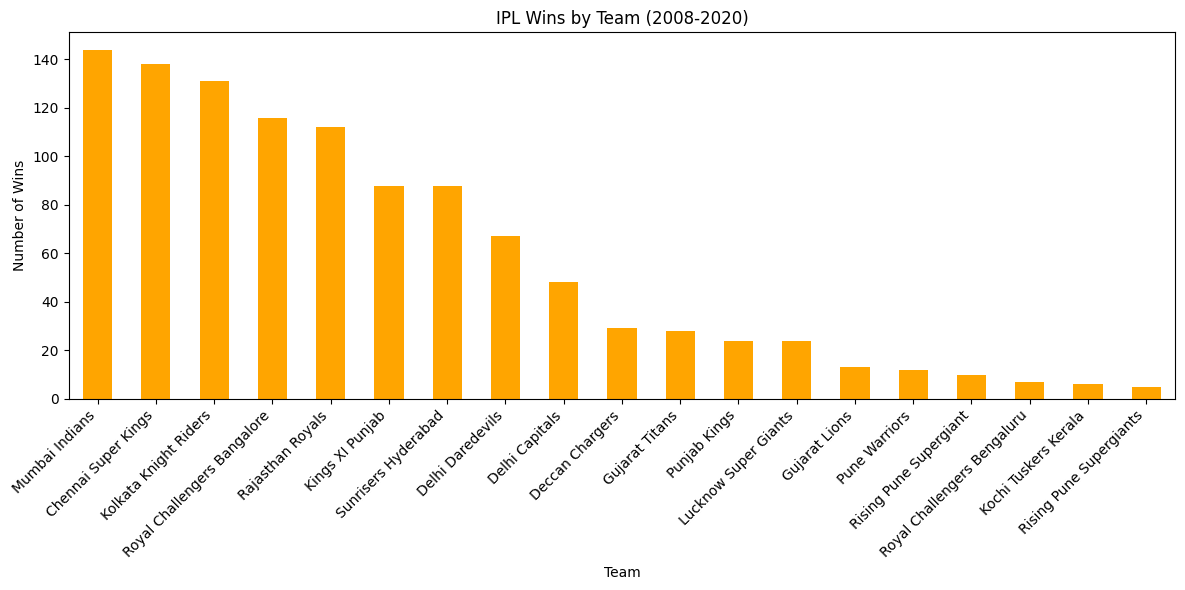

In [2]:
# How many matches each team won
team_wins = matches['winner'].value_counts()
print("Team Win Counts:")
print(team_wins)

# Plot it!
plt.figure(figsize=(12,6))
team_wins.plot(kind='bar', color='orange')
plt.title('IPL Wins by Team (2008-2020)')
plt.xlabel('Team')
plt.ylabel('Number of Wins')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

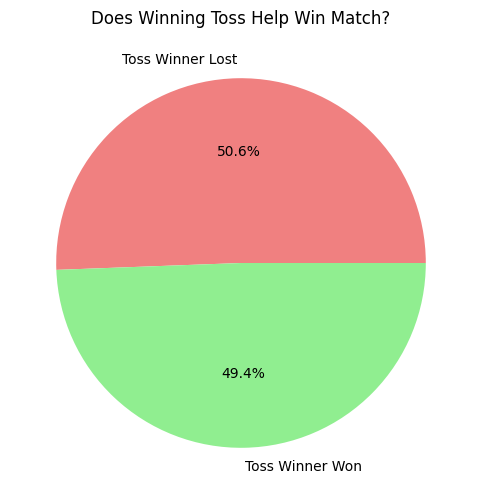

In [3]:
# Toss winner vs Match winner analysis
matches['toss_match_win'] = matches['toss_winner'] == matches['winner']
toss_effect = matches['toss_match_win'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(toss_effect, labels=['Toss Winner Lost', 'Toss Winner Won'], 
        autopct='%1.1f%%', colors=['lightcoral', 'lightgreen'])
plt.title('Does Winning Toss Help Win Match?')
plt.show()

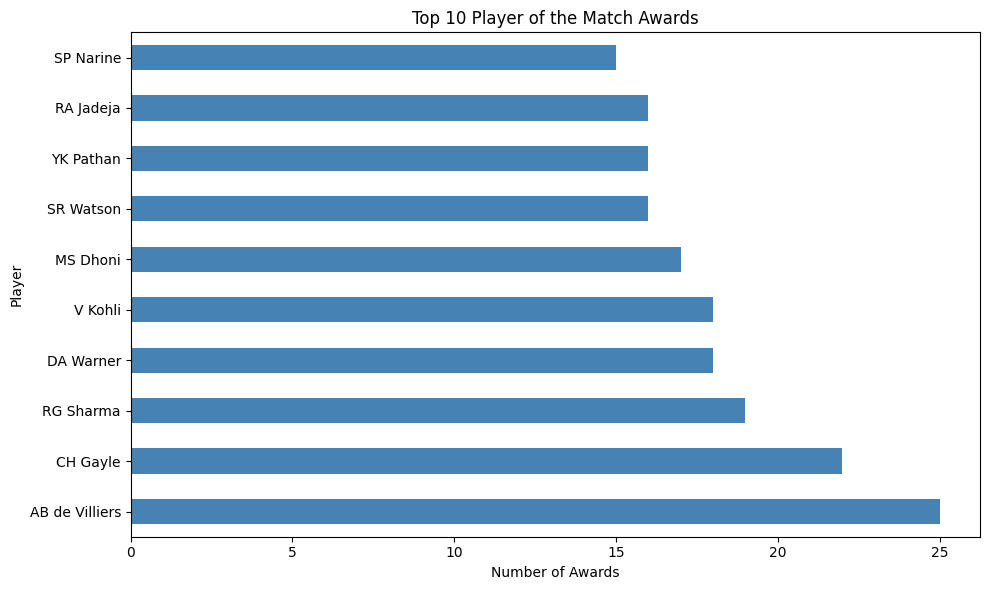

In [4]:
# Top 10 Player of the Match
top_players = matches['player_of_match'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_players.plot(kind='barh', color='steelblue')
plt.title('Top 10 Player of the Match Awards')
plt.xlabel('Number of Awards')
plt.ylabel('Player')
plt.tight_layout()
plt.show()

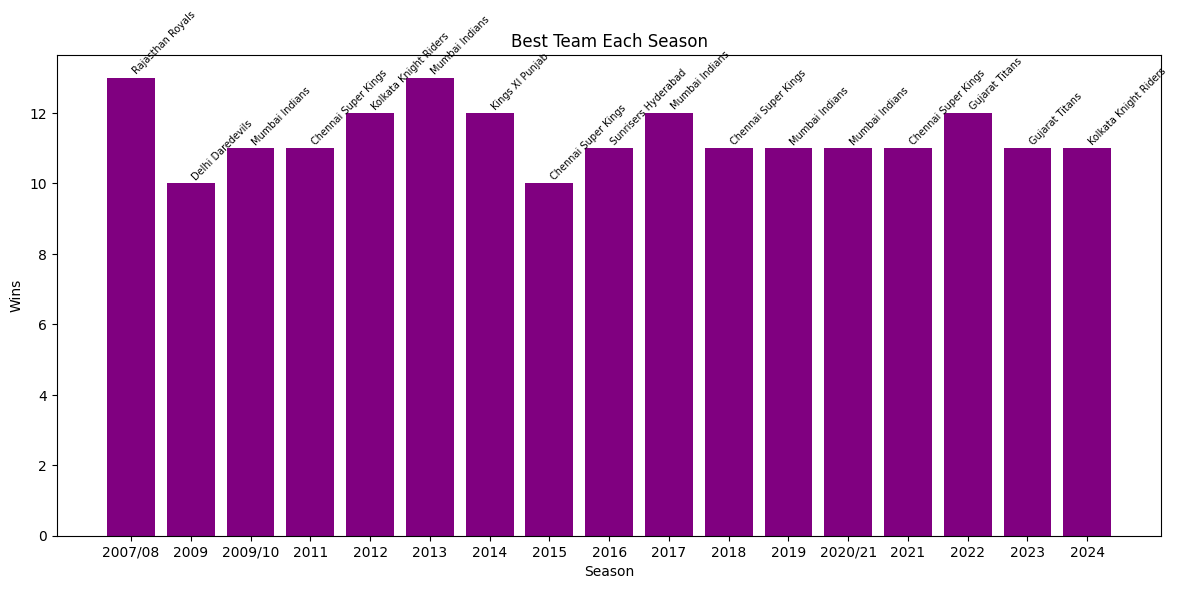

In [5]:
# Most wins per season
season_wins = matches.groupby(['season', 'winner']).size().reset_index(name='wins')
top_season = season_wins.loc[season_wins.groupby('season')['wins'].idxmax()]

plt.figure(figsize=(12,6))
plt.bar(top_season['season'], top_season['wins'], color='purple')
plt.title('Best Team Each Season')
plt.xlabel('Season')
plt.ylabel('Wins')
for i, row in top_season.iterrows():
    plt.text(row['season'], row['wins']+0.1, row['winner'], 
             rotation=45, fontsize=7, ha='left')
plt.tight_layout()
plt.show()

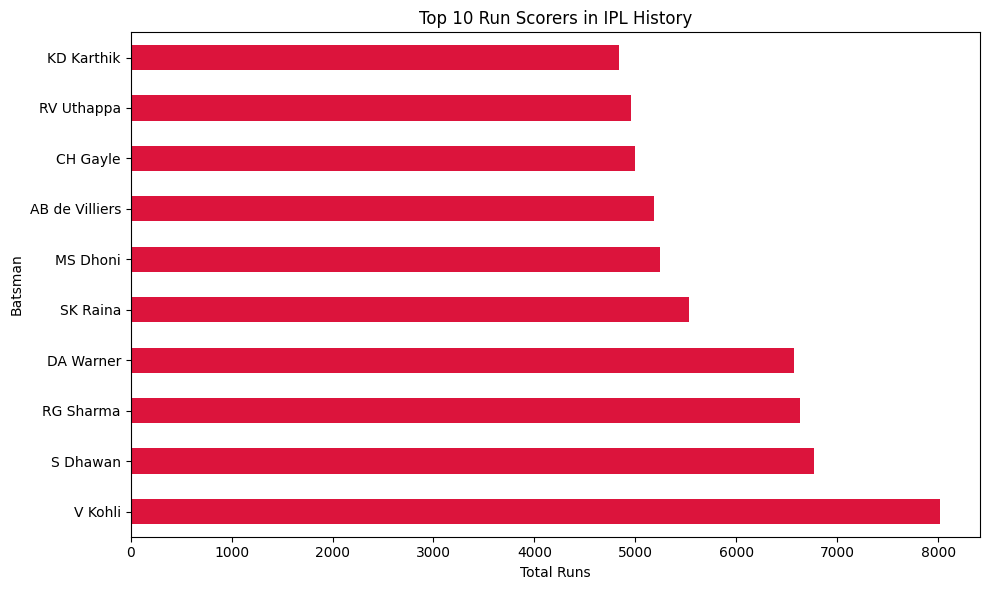

In [6]:
# Top 10 batsmen by total runs
top_batsmen = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_batsmen.plot(kind='barh', color='crimson')
plt.title('Top 10 Run Scorers in IPL History')
plt.xlabel('Total Runs')
plt.ylabel('Batsman')
plt.tight_layout()
plt.show()

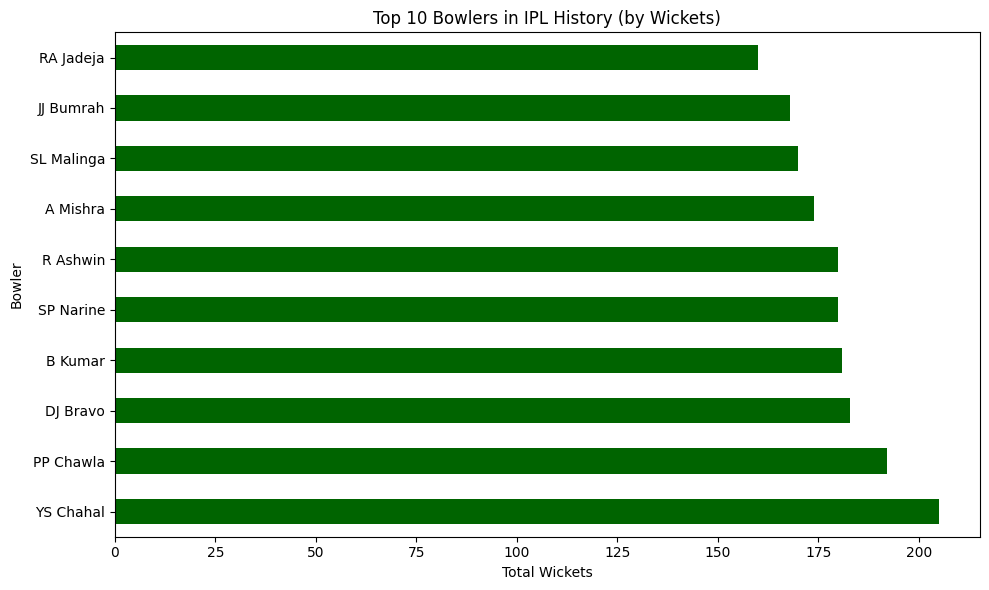

In [7]:
# Top 10 Bowlers by wickets
# Removing non-wicket dismissals
not_wickets = ['run out', 'retired hurt', 'obstructing the field']
wickets_df = deliveries[~deliveries['dismissal_kind'].isin(not_wickets) & 
                         deliveries['dismissal_kind'].notna()]

top_bowlers = wickets_df.groupby('bowler')['dismissal_kind'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_bowlers.plot(kind='barh', color='darkgreen')
plt.title('Top 10 Bowlers in IPL History (by Wickets)')
plt.xlabel('Total Wickets')
plt.ylabel('Bowler')
plt.tight_layout()
plt.show()

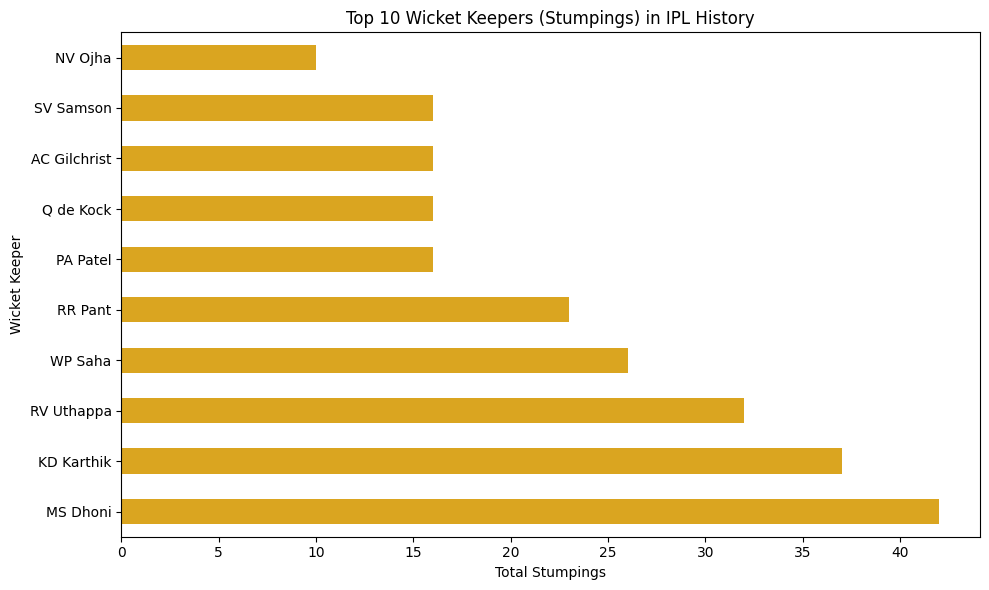

In [8]:
# Best Wicket Keepers (stumpings + caught behind)
wk_dismissals = deliveries[deliveries['dismissal_kind'].isin(['stumped', 'caught and bowled'])]

# Caught by wicketkeeper
caught_wk = deliveries[deliveries['dismissal_kind'] == 'caught']

top_wk = deliveries[deliveries['dismissal_kind'].isin(['stumped'])].groupby('fielder')['dismissal_kind'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_wk.plot(kind='barh', color='goldenrod')
plt.title('Top 10 Wicket Keepers (Stumpings) in IPL History')
plt.xlabel('Total Stumpings')
plt.ylabel('Wicket Keeper')
plt.tight_layout()
plt.show()

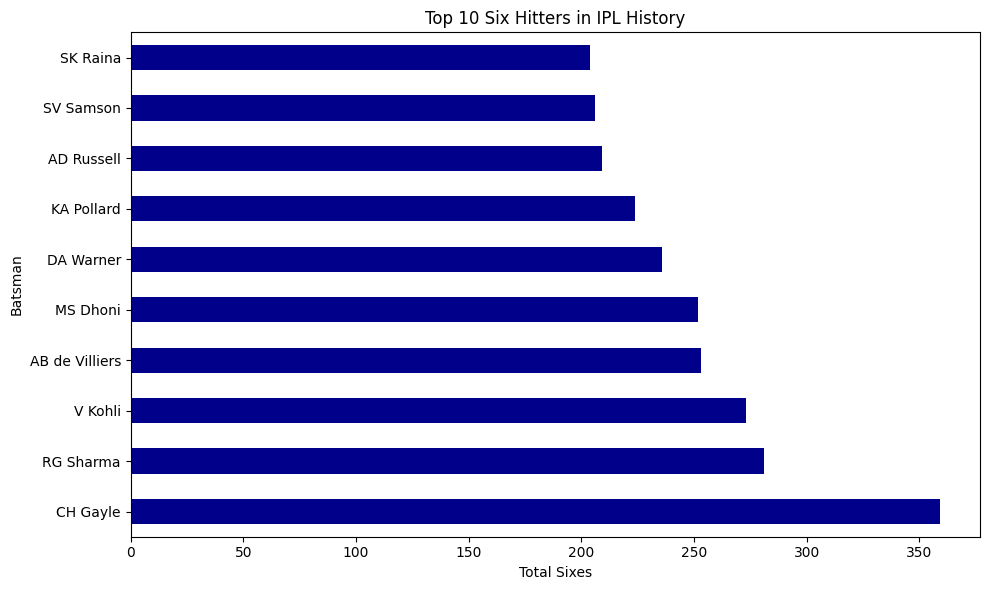

In [9]:
# Most Sixes in IPL History
sixes = deliveries[deliveries['batsman_runs'] == 6]
top_six_hitters = sixes.groupby('batter')['batsman_runs'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_six_hitters.plot(kind='barh', color='darkblue')
plt.title('Top 10 Six Hitters in IPL History')
plt.xlabel('Total Sixes')
plt.ylabel('Batsman')
plt.tight_layout()
plt.show()

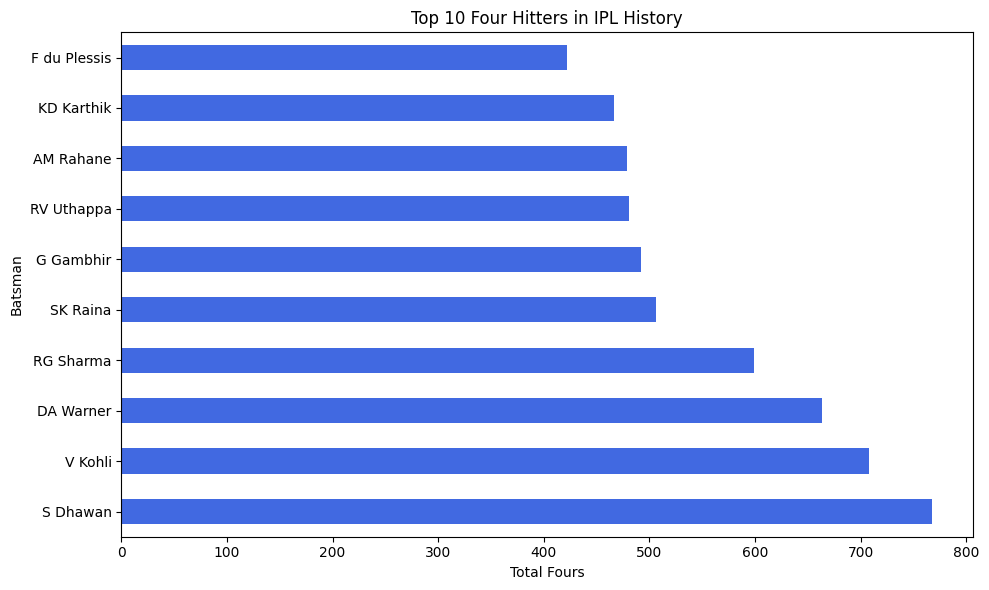

In [10]:
# Most number of 4s
fours = deliveries[deliveries['batsman_runs'] == 4]
top_four_hitters = fours.groupby('batter')['batsman_runs'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_four_hitters.plot(kind='barh', color='royalblue')
plt.title('Top 10 Four Hitters in IPL History')
plt.xlabel('Total Fours')
plt.ylabel('Batsman')
plt.tight_layout()
plt.show()



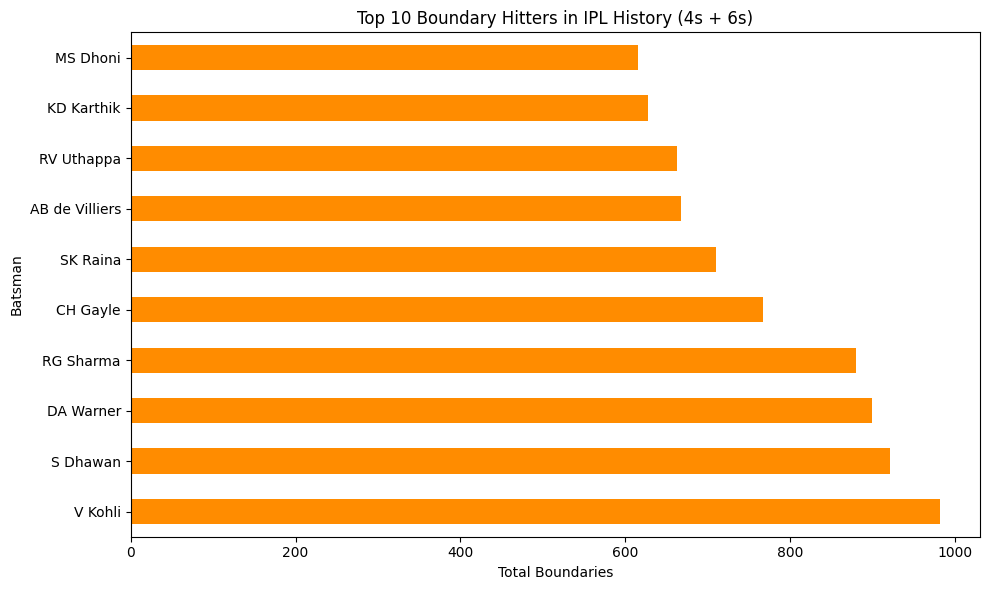

In [11]:
# Most number of boundaries (4s + 6s)
boundaries = deliveries[deliveries['batsman_runs'].isin([4, 6])]
top_boundary_hitters = boundaries.groupby('batter')['batsman_runs'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_boundary_hitters.plot(kind='barh', color='darkorange')
plt.title('Top 10 Boundary Hitters in IPL History (4s + 6s)')
plt.xlabel('Total Boundaries')
plt.ylabel('Batsman')
plt.tight_layout()
plt.show()



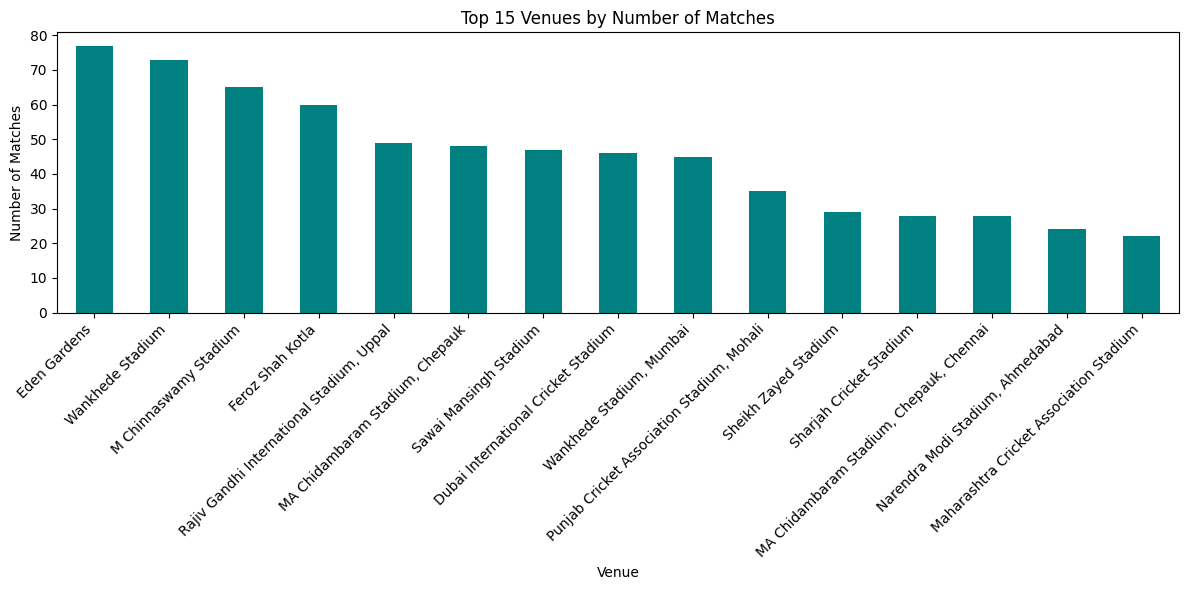

In [12]:
# Venue wise match count
venue_counts = matches['venue'].value_counts().head(15)

plt.figure(figsize=(12,6))
venue_counts.plot(kind='bar', color='teal')
plt.title('Top 15 Venues by Number of Matches')
plt.xlabel('Venue')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



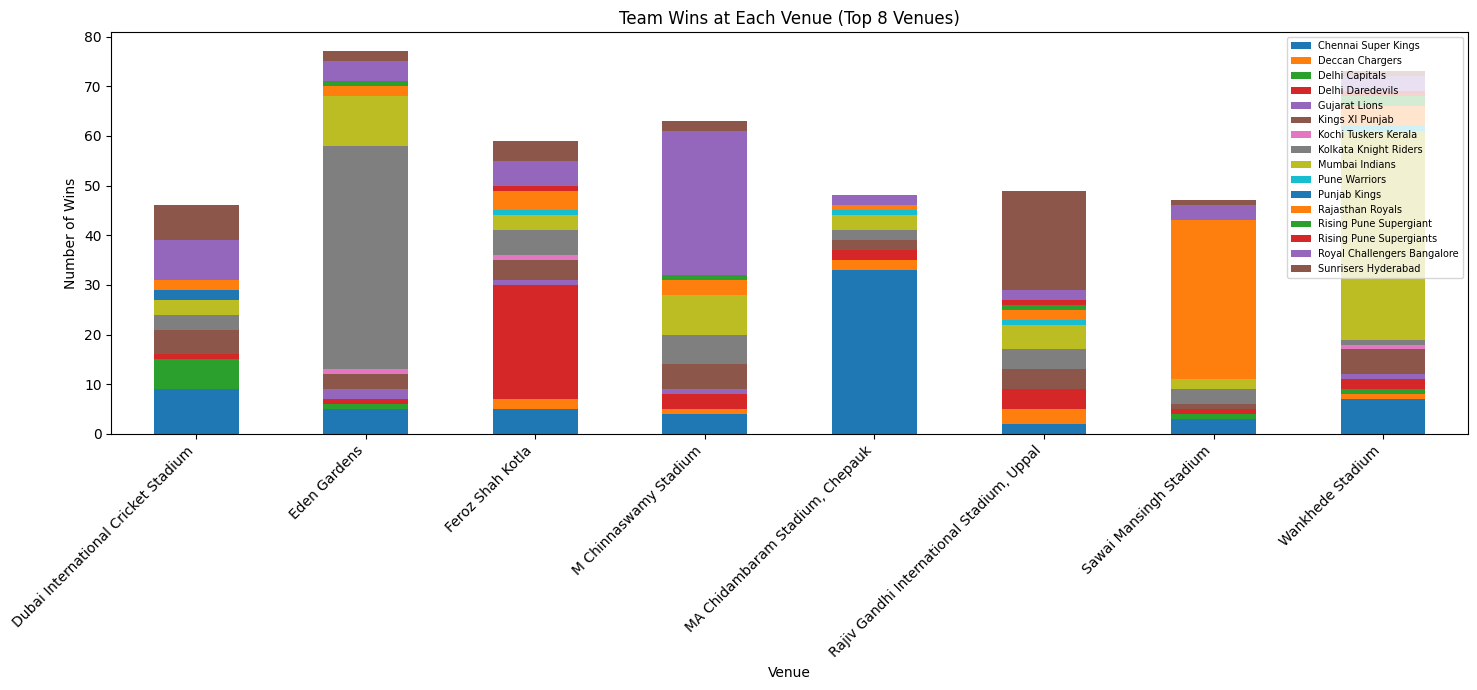

In [13]:
# Each team wins in each venue
team_venue_wins = matches.groupby(['venue', 'winner']).size().reset_index(name='wins')
top_venues = matches['venue'].value_counts().head(8).index
filtered = team_venue_wins[team_venue_wins['venue'].isin(top_venues)]

import matplotlib.pyplot as plt
pivot_data = filtered.pivot(index='venue', columns='winner', values='wins').fillna(0)

pivot_data.plot(kind='bar', figsize=(15,7), stacked=True)
plt.title('Team Wins at Each Venue (Top 8 Venues)')
plt.xlabel('Venue')
plt.ylabel('Number of Wins')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right', fontsize=7)
plt.tight_layout()
plt.show()

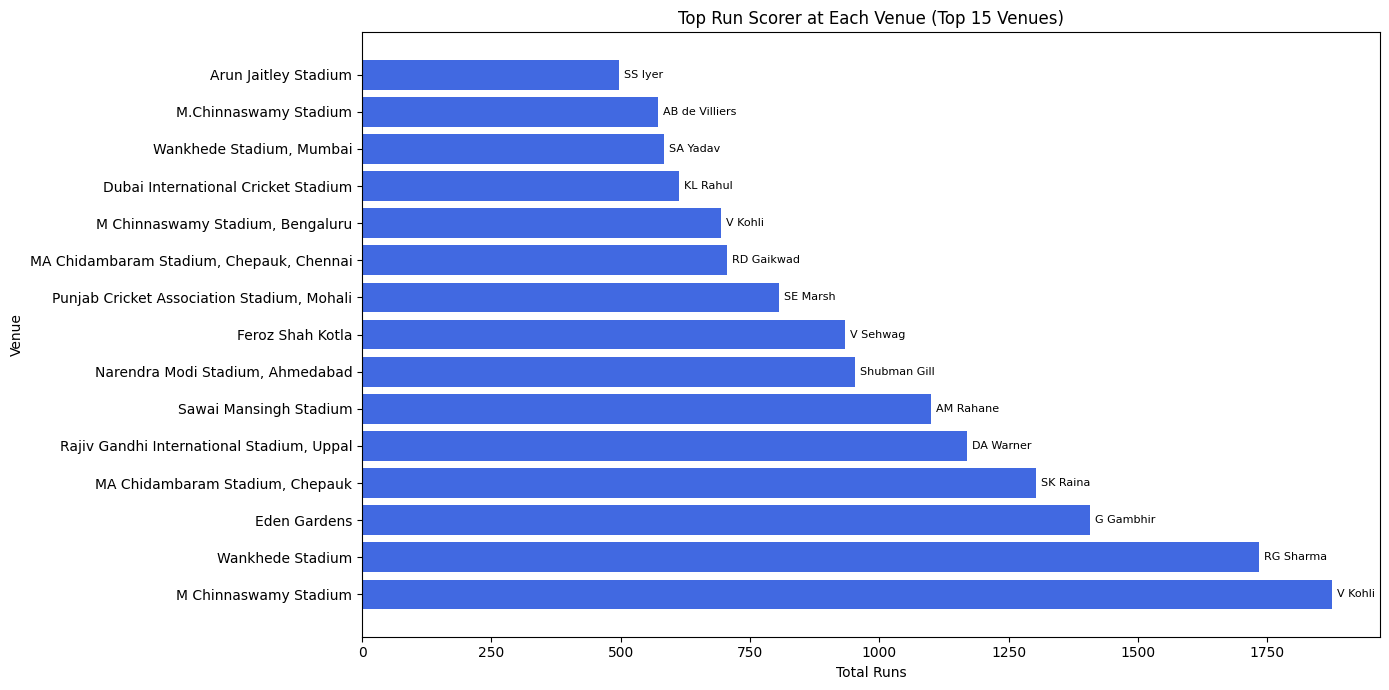

In [14]:
# Top batter in each venue
venue_batsman = deliveries.merge(matches[['id', 'venue']], left_on='match_id', right_on='id')
top_batter_venue = venue_batsman.groupby(['venue', 'batter'])['batsman_runs'].sum().reset_index()
top_batter_per_venue = top_batter_venue.loc[top_batter_venue.groupby('venue')['batsman_runs'].idxmax()]
top_batter_per_venue = top_batter_per_venue.sort_values('batsman_runs', ascending=False).head(15)

plt.figure(figsize=(14,7))
plt.barh(top_batter_per_venue['venue'], top_batter_per_venue['batsman_runs'], color='royalblue')
for i, row in top_batter_per_venue.iterrows():
    plt.text(row['batsman_runs']+10, list(top_batter_per_venue['venue']).index(row['venue']), 
             row['batter'], fontsize=8, va='center')
plt.title('Top Run Scorer at Each Venue (Top 15 Venues)')
plt.xlabel('Total Runs')
plt.ylabel('Venue')
plt.tight_layout()
plt.show()

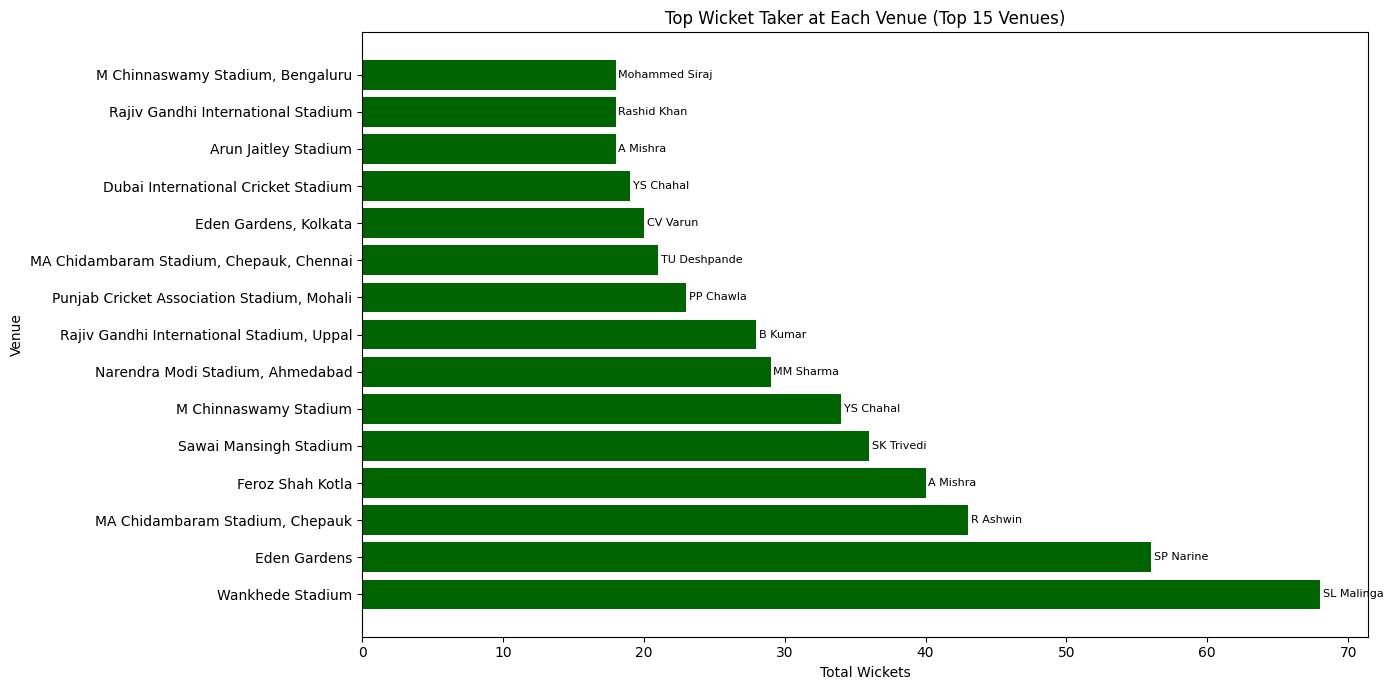

In [15]:
# Top bowler in each venue
not_wickets = ['run out', 'retired hurt', 'obstructing the field']
wickets_only = deliveries[~deliveries['dismissal_kind'].isin(not_wickets) & 
                           deliveries['dismissal_kind'].notna()]

venue_bowler = wickets_only.merge(matches[['id', 'venue']], left_on='match_id', right_on='id')
top_bowler_venue = venue_bowler.groupby(['venue', 'bowler'])['dismissal_kind'].count().reset_index(name='wickets')
top_bowler_per_venue = top_bowler_venue.loc[top_bowler_venue.groupby('venue')['wickets'].idxmax()]
top_bowler_per_venue = top_bowler_per_venue.sort_values('wickets', ascending=False).head(15)

plt.figure(figsize=(14,7))
plt.barh(top_bowler_per_venue['venue'], top_bowler_per_venue['wickets'], color='darkgreen')
for i, row in top_bowler_per_venue.iterrows():
    plt.text(row['wickets']+0.2, list(top_bowler_per_venue['venue']).index(row['venue']),
             row['bowler'], fontsize=8, va='center')
plt.title('Top Wicket Taker at Each Venue (Top 15 Venues)')
plt.xlabel('Total Wickets')
plt.ylabel('Venue')
plt.tight_layout()
plt.show()

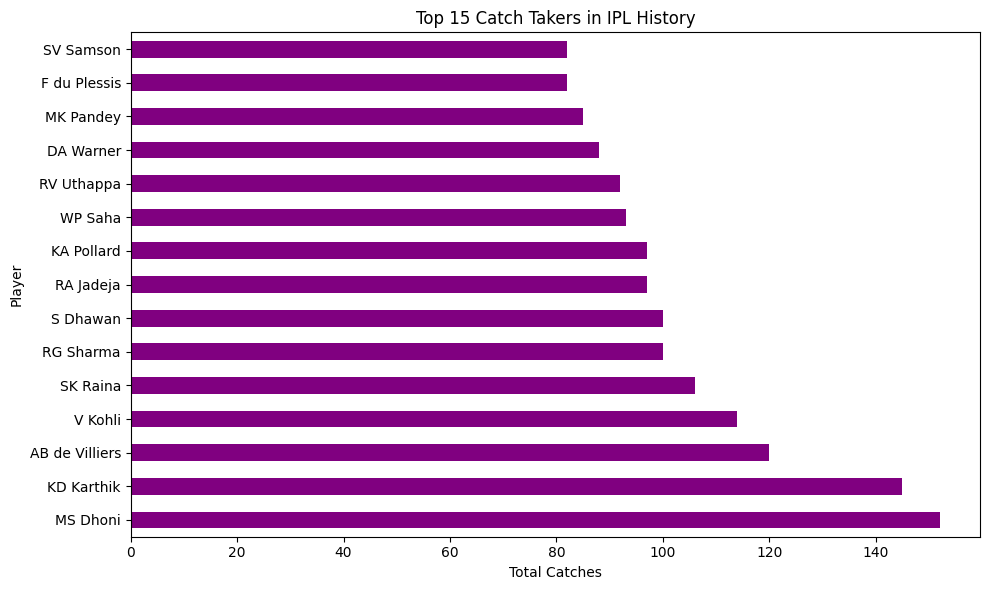


Top 15 Catch Takers:
fielder
MS Dhoni          152
KD Karthik        145
AB de Villiers    120
V Kohli           114
SK Raina          106
RG Sharma         100
S Dhawan          100
RA Jadeja          97
KA Pollard         97
WP Saha            93
RV Uthappa         92
DA Warner          88
MK Pandey          85
F du Plessis       82
SV Samson          82
Name: dismissal_kind, dtype: int64


In [16]:
# Number of catches taken by every player (top 15)
catches = deliveries[deliveries['dismissal_kind'] == 'caught']
top_catchers = catches.groupby('fielder')['dismissal_kind'].count().sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
top_catchers.plot(kind='barh', color='purple')
plt.title('Top 15 Catch Takers in IPL History')
plt.xlabel('Total Catches')
plt.ylabel('Player')
plt.tight_layout()
plt.show()

print("\nTop 15 Catch Takers:")
print(top_catchers)

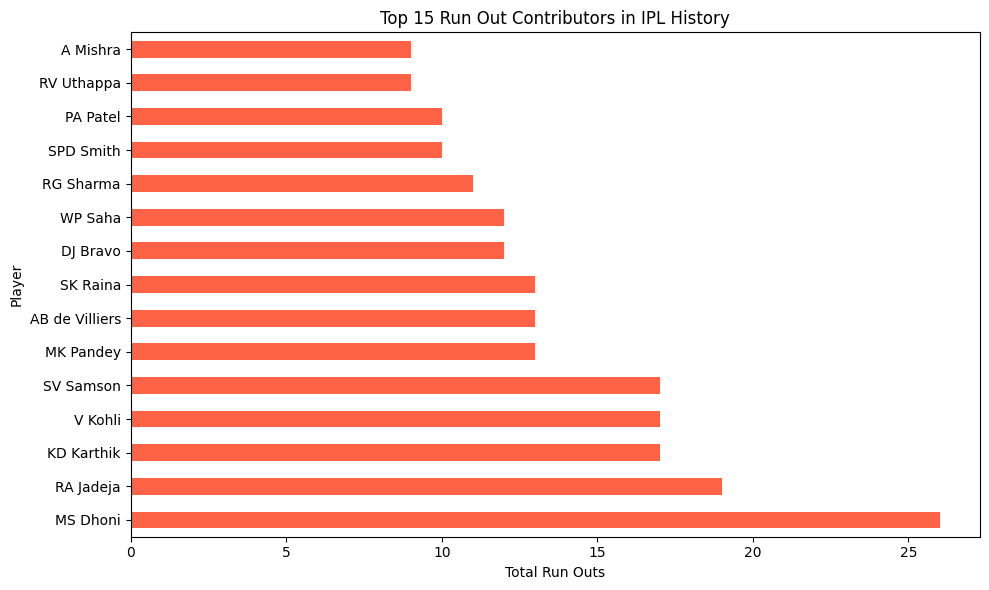


Top 15 Run Out Contributors:
fielder
MS Dhoni          26
RA Jadeja         19
KD Karthik        17
V Kohli           17
SV Samson         17
MK Pandey         13
AB de Villiers    13
SK Raina          13
DJ Bravo          12
WP Saha           12
RG Sharma         11
SPD Smith         10
PA Patel          10
RV Uthappa         9
A Mishra           9
Name: dismissal_kind, dtype: int64


In [17]:
# Run outs by each player
run_outs = deliveries[deliveries['dismissal_kind'] == 'run out']
top_runouts = run_outs.groupby('fielder')['dismissal_kind'].count().sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
top_runouts.plot(kind='barh', color='tomato')
plt.title('Top 15 Run Out Contributors in IPL History')
plt.xlabel('Total Run Outs')
plt.ylabel('Player')
plt.tight_layout()
plt.show()

print("\nTop 15 Run Out Contributors:")
print(top_runouts)

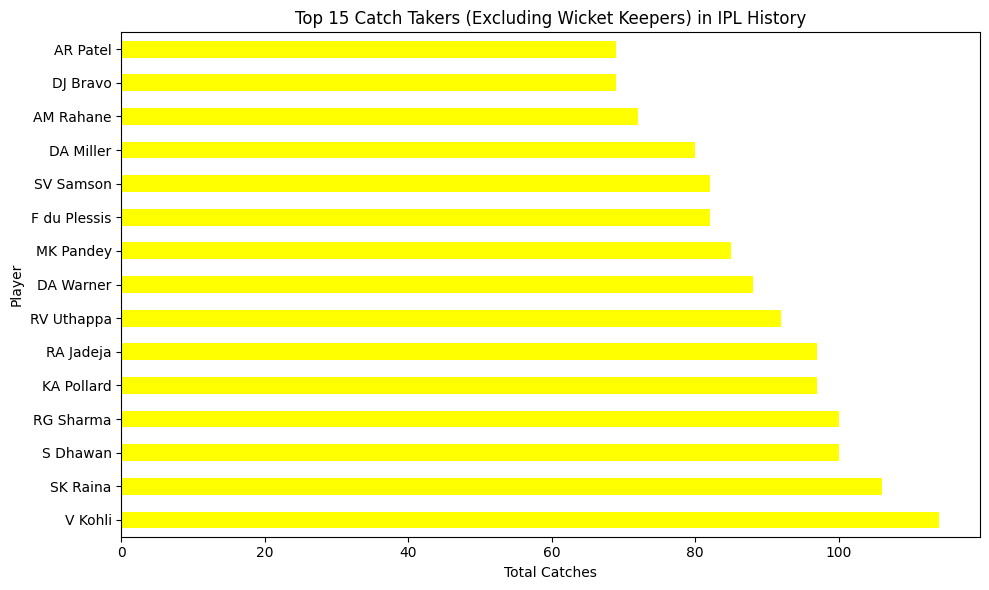


Top 15 Non-WK Catch Takers:
fielder
V Kohli         114
SK Raina        106
S Dhawan        100
RG Sharma       100
KA Pollard       97
RA Jadeja        97
RV Uthappa       92
DA Warner        88
MK Pandey        85
F du Plessis     82
SV Samson        82
DA Miller        80
AM Rahane        72
DJ Bravo         69
AR Patel         69
Name: dismissal_kind, dtype: int64


In [18]:
# Known wicket keepers list
wicket_keepers = ['MS Dhoni', 'AB de Villiers', 'KL Rahul', 'R Parthiv', 
                   'Parthiv Patel', 'DK Dinesh', 'NV Ojha', 'RR Pant', 
                   'Rishabh Pant', 'Q de Kock', 'Quinton de Kock',
                   'KD Karthik', 'Dinesh Karthik', 'SW Billings', 
                   'Ishan Kishan', 'Sanju Samson', 'CM Gautam',
                   'PA Patel', 'WP Saha', 'Wriddhiman Saha']

# Catches excluding wicket keepers
catches = deliveries[deliveries['dismissal_kind'] == 'caught']
non_wk_catches = catches[~catches['fielder'].isin(wicket_keepers)]
top_non_wk_catchers = non_wk_catches.groupby('fielder')['dismissal_kind'].count().sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
top_non_wk_catchers.plot(kind='barh', color='yellow')
plt.title('Top 15 Catch Takers (Excluding Wicket Keepers) in IPL History')
plt.xlabel('Total Catches')
plt.ylabel('Player')
plt.tight_layout()
plt.show()

print("\nTop 15 Non-WK Catch Takers:")
print(top_non_wk_catchers)

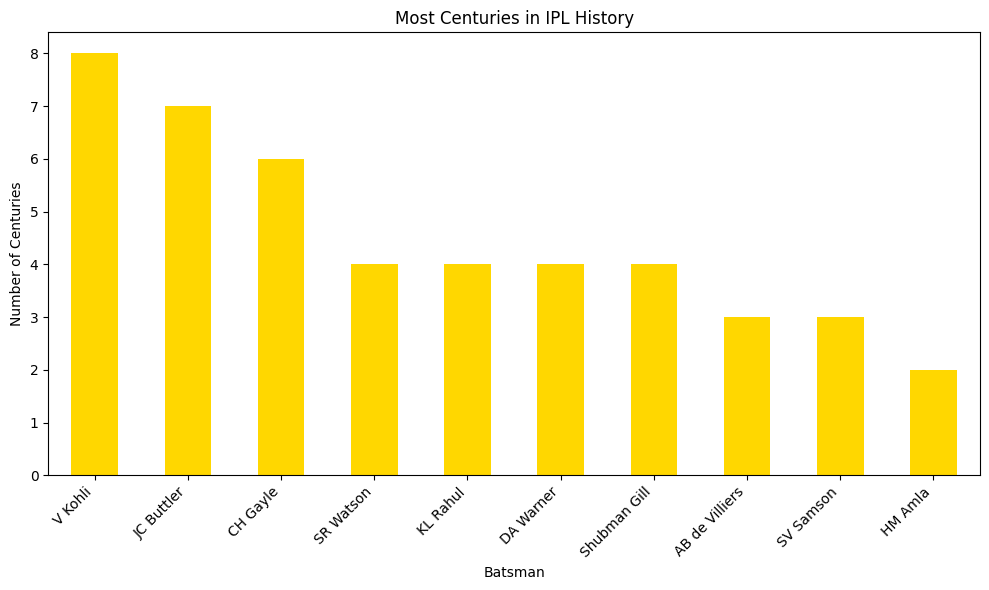


Century Makers:
               batter  batsman_runs
5315         CH Gayle           175
0         BB McCullum           158
14171       Q de Kock           140
7556   AB de Villiers           133
11623        KL Rahul           132
...               ...           ...
8034          V Kohli           100
6714      LMP Simmons           100
6940      BB McCullum           100
10960         V Kohli           100
10234       AT Rayudu           100

[101 rows x 2 columns]


In [19]:
# Centuries in IPL
runs_per_innings = deliveries.groupby(['match_id', 'inning', 'batter'])['batsman_runs'].sum().reset_index()
centuries = runs_per_innings[runs_per_innings['batsman_runs'] >= 100]
top_century_makers = centuries.groupby('batter')['batsman_runs'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_century_makers.plot(kind='bar', color='gold')
plt.title('Most Centuries in IPL History')
plt.xlabel('Batsman')
plt.ylabel('Number of Centuries')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nCentury Makers:")
print(centuries[['batter', 'batsman_runs']].sort_values('batsman_runs', ascending=False))